# Demand Forecasting & Inventory Planning

## Objective
The objective of this project is to forecast product demand using historical sales data and evaluate multiple forecasting techniques to support inventory planning.

## Project Workflow
1. Data Loading
2. Data Cleaning
3. Exploratory Data Analysis
4. Monthly Demand Aggregation
5. Train-Test Split
6. Forecasting Models
7. Model Evaluation
8. Future Demand Forecast
9. Inventory Planning


## Limitations

- The selected product has only 24 monthly observations, so the forecasting results should be interpreted as a portfolio/project demonstration rather than a production-ready forecasting system.
- A major demand shift occurred between 2012 and 2013, which may affect model stability.
- The analysis uses historical demand only and does not include external factors such as price, promotions, market conditions, or customer-specific information.
- The inventory recommendations are illustrative and depend on assumed lead time and service level.

## Business Recommendations

- Use the ARIMA forecast as a planning input for short-term production and inventory decisions.
- Expected demand for the next six months is approximately 1.79–2.04 million units per month.
- Under the assumed 1-month lead time and 95% service level, the illustrative safety stock is approximately 565,041 units.
- The illustrative reorder point is approximately 2,178,541 units.
- Forecasts should be periodically updated as new demand data becomes available.
- Production and inventory decisions should also consider lead time, capacity, supplier constraints, and changes in market demand.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_absolute_error, mean_squared_error

In [5]:
df = pd.read_csv("Historical Product Demand.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (214014, 5)


,Product_Code,Warehouse,Product_Category,Date,Order_Demand
0,Product_0993,Whse_J,Category_028,2012/7/27,100
1,Product_0979,Whse_J,Category_028,2012/1/19,500
2,Product_0979,Whse_J,Category_028,2012/2/3,500
3,Product_0979,Whse_J,Category_028,2012/2/9,500
4,Product_0979,Whse_J,Category_028,2012/3/2,500


In [6]:
print("Column names:")
print(df.columns.tolist())

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())


Column names:
['Product_Code', 'Warehouse', 'Product_Category', 'Date', 'Order_Demand']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214014 entries, 0 to 214013
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Product_Code      214014 non-null  object
 1   Warehouse         214014 non-null  object
 2   Product_Category  214014 non-null  object
 3   Date              214012 non-null  object
 4   Order_Demand      214013 non-null  object
dtypes: object(5)
memory usage: 8.2+ MB

Missing values:
Product_Code        0
Warehouse           0
Product_Category    0
Date                2
Order_Demand        1
dtype: int64


In [7]:
df.head(10)

,Product_Code,Warehouse,Product_Category,Date,Order_Demand
0,Product_0993,Whse_J,Category_028,2012/7/27,100
1,Product_0979,Whse_J,Category_028,2012/1/19,500
2,Product_0979,Whse_J,Category_028,2012/2/3,500
3,Product_0979,Whse_J,Category_028,2012/2/9,500
4,Product_0979,Whse_J,Category_028,2012/3/2,500
5,Product_0979,Whse_J,Category_028,2012/4/19,500
6,Product_0979,Whse_J,Category_028,2012/6/5,500
7,Product_0979,Whse_J,Category_028,2012/6/27,500
8,Product_0979,Whse_J,Category_028,2012/7/23,500
9,Product_0979,Whse_J,Category_028,2012/8/29,500


In [8]:
df.tail(10)


,Product_Code,Warehouse,Product_Category,Date,Order_Demand
214004,Product_1735,Whse_S,Category_030,2013/3/19,1000
214005,Product_0374,Whse_S,Category_030,2013/3/26,1000
214006,Product_0387,Whse_S,Category_030,2013/3/26,1000
214007,Product_1740,Whse_S,Category_030,2013/3/26,3000
214008,Product_0387,Whse_S,Category_030,2013/5/21,20000
214009,Product_0374,Whse_S,Category_030,2013/3/22,10000
214010,Product_0387,Whse_S,Category_030,2013/3/22,2000
214011,Product_1743,Whse_S,Category_030,2013/3/22,2000
214012,Product_0374,Whse_S,Category_030,2013/3/27,1000
214013,Product_0374,Whse_S,Categ,NaN,NaN


In [9]:
# Convert Date to datetime
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Convert Order_Demand to numeric
df["Order_Demand"] = pd.to_numeric(df["Order_Demand"], errors="coerce")

# Remove rows with missing Date or Demand
df = df.dropna(subset=["Date", "Order_Demand"])

# Sort by date
df = df.sort_values("Date")

print("Cleaned dataset shape:", df.shape)

df.head()

Cleaned dataset shape: (212655, 5)


,Product_Code,Warehouse,Product_Category,Date,Order_Demand
44799,Product_0965,Whse_A,Category_006,2011-01-08,2.0
72252,Product_1724,Whse_A,Category_003,2011-05-31,108.0
8431,Product_1521,Whse_S,Category_019,2011-06-24,85000.0
8432,Product_1521,Whse_S,Category_019,2011-06-24,7000.0
72669,Product_1507,Whse_C,Category_019,2011-09-02,1250.0


In [10]:
# Convert Date to datetime
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Convert Order_Demand to numeric
df["Order_Demand"] = pd.to_numeric(df["Order_Demand"], errors="coerce")

# Remove rows where Date or Demand is missing
df = df.dropna(subset=["Date", "Order_Demand"])

# Sort the data chronologically
df = df.sort_values("Date")

print("Cleaned dataset shape:", df.shape)
print(df.dtypes)

Cleaned dataset shape: (212655, 5)
Product_Code                object
Warehouse                   object
Product_Category            object
Date                datetime64[ns]
Order_Demand               float64
dtype: object


In [11]:
product_demand = (
    df.groupby("Product_Code")["Order_Demand"]
      .sum()
      .sort_values(ascending=False)
)

print(product_demand.head(10))


Product_Code
Product_1359    113708000.0
Product_1341     57548000.0
Product_1248     57139000.0
Product_0083     39021000.0
Product_1245     32649000.0
Product_1432     25904000.0
Product_1241     25065000.0
Product_1295     22624200.0
Product_1274     21388000.0
Product_1574     20273500.0
Name: Order_Demand, dtype: float64


In [12]:
product = df[df["Product_Code"] == "Product_1359"].copy()

print("Number of records:", len(product))
print("Start date:", product["Date"].min())
print("End date:", product["Date"].max())

product.head()

Number of records: 4260
Start date: 2012-01-05 00:00:00
End date: 2013-12-26 00:00:00


,Product_Code,Warehouse,Product_Category,Date,Order_Demand
46739,Product_1359,Whse_J,Category_019,2012-01-05,5000.0
7940,Product_1359,Whse_J,Category_019,2012-01-05,100000.0
20412,Product_1359,Whse_J,Category_019,2012-01-05,150000.0
63083,Product_1359,Whse_J,Category_019,2012-01-05,1000.0
63087,Product_1359,Whse_J,Category_019,2012-01-05,16000.0


In [13]:
# Set Date as the index
product = product.set_index("Date")

# Calculate total demand for each month
monthly_demand = product["Order_Demand"].resample("ME").sum()

print("Number of months:", len(monthly_demand))
print(monthly_demand.head(10))

Number of months: 24
Date
2012-01-31    8910000.0
2012-02-29    8071000.0
2012-03-31    7700000.0
2012-04-30    8900000.0
2012-05-31    8475000.0
2012-06-30    6531000.0
2012-07-31    7422000.0
2012-08-31    6667000.0
2012-09-30    7849000.0
2012-10-31    7676000.0
Freq: ME, Name: Order_Demand, dtype: float64


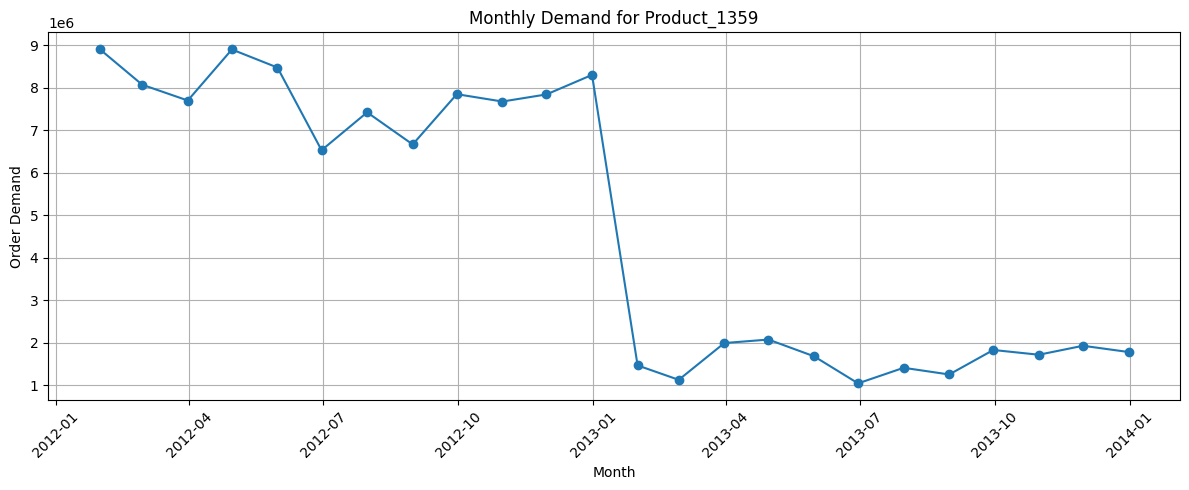

In [14]:
plt.figure(figsize=(12, 5))

plt.plot(monthly_demand.index, monthly_demand.values, marker="o")

plt.title("Monthly Demand for Product_1359")
plt.xlabel("Month")
plt.ylabel("Order Demand")
plt.xticks(rotation=45)

plt.grid(True)
plt.tight_layout()
plt.show()

In [15]:
print(monthly_demand)

Date
2012-01-31    8910000.0
2012-02-29    8071000.0
2012-03-31    7700000.0
2012-04-30    8900000.0
2012-05-31    8475000.0
2012-06-30    6531000.0
2012-07-31    7422000.0
2012-08-31    6667000.0
2012-09-30    7849000.0
2012-10-31    7676000.0
2012-11-30    7843000.0
2012-12-31    8302000.0
2013-01-31    1471000.0
2013-02-28    1132000.0
2013-03-31    1997000.0
2013-04-30    2079000.0
2013-05-31    1686000.0
2013-06-30    1049000.0
2013-07-31    1415000.0
2013-08-31    1258000.0
2013-09-30    1834000.0
2013-10-31    1722000.0
2013-11-30    1933000.0
2013-12-31    1786000.0
Freq: ME, Name: Order_Demand, dtype: float64


In [16]:
# Use 2013 demand for forecasting
forecast_data = monthly_demand["2013"].copy()

# Training: first 9 months
train = forecast_data.iloc[:9]

# Testing: last 3 months
test = forecast_data.iloc[9:]

print("Training data:")
print(train)

print("\nTesting data:")
print(test)

Training data:
Date
2013-01-31    1471000.0
2013-02-28    1132000.0
2013-03-31    1997000.0
2013-04-30    2079000.0
2013-05-31    1686000.0
2013-06-30    1049000.0
2013-07-31    1415000.0
2013-08-31    1258000.0
2013-09-30    1834000.0
Freq: ME, Name: Order_Demand, dtype: float64

Testing data:
Date
2013-10-31    1722000.0
2013-11-30    1933000.0
2013-12-31    1786000.0
Freq: ME, Name: Order_Demand, dtype: float64


In [17]:
# 3-month moving average forecast
moving_average_forecast = train.rolling(window=3).mean()

print("Moving Average Forecast:")
print(moving_average_forecast)

Moving Average Forecast:
Date
2013-01-31             NaN
2013-02-28             NaN
2013-03-31    1.533333e+06
2013-04-30    1.736000e+06
2013-05-31    1.920667e+06
2013-06-30    1.604667e+06
2013-07-31    1.383333e+06
2013-08-31    1.240667e+06
2013-09-30    1.502333e+06
Freq: ME, Name: Order_Demand, dtype: float64


In [18]:
# Make a copy of the training data
history = train.copy()

predictions = []

# Forecast October, November and December
for i in range(len(test)):
    forecast = history.iloc[-3:].mean()
    predictions.append(forecast)

    # Add the predicted value to history
    history = pd.concat([
        history,
        pd.Series([forecast], index=[test.index[i]])
    ])

predictions = pd.Series(predictions, index=test.index)

print("Moving Average Forecast:")
print(predictions)

Moving Average Forecast:
Date
2013-10-31    1.502333e+06
2013-11-30    1.531444e+06
2013-12-31    1.622593e+06
Freq: ME, dtype: float64


In [19]:
# Evaluate the Moving Average model

mae = mean_absolute_error(test, predictions)

rmse = np.sqrt(mean_squared_error(test, predictions))

mape = np.mean(np.abs((test - predictions) / test)) * 100

print("Moving Average Model Performance")
print("--------------------------------")
print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"MAPE : {mape:.2f}%")


Moving Average Model Performance
--------------------------------
MAE  : 261,543.21
RMSE : 280,595.97
MAPE : 14.23%


In [20]:
# Exponential Smoothing model

model = ExponentialSmoothing(
    train,
    trend=None,
    seasonal=None
)

fitted_model = model.fit()

exp_predictions = fitted_model.forecast(len(test))

print("Exponential Smoothing Forecast:")
print(exp_predictions)

Exponential Smoothing Forecast:
2013-10-31    1.546499e+06
2013-11-30    1.546499e+06
2013-12-31    1.546499e+06
Freq: ME, dtype: float64


In [21]:
# Evaluate Exponential Smoothing

mae_exp = mean_absolute_error(test, exp_predictions)

rmse_exp = np.sqrt(mean_squared_error(test, exp_predictions))

mape_exp = np.mean(
    np.abs((test - exp_predictions) / test)
) * 100

print("\nExponential Smoothing Performance")
print("--------------------------------")
print(f"MAE  : {mae_exp:,.2f}")
print(f"RMSE : {rmse_exp:,.2f}")
print(f"MAPE : {mape_exp:.2f}%")


Exponential Smoothing Performance
--------------------------------
MAE  : 267,167.93
RMSE : 281,392.24
MAPE : 14.53%


In [22]:
# ARIMA model

arima_model = ARIMA(train, order=(1, 1, 1))

arima_fitted = arima_model.fit()

arima_predictions = arima_fitted.forecast(steps=len(test))

print("ARIMA Forecast:")
print(arima_predictions)

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


ARIMA Forecast:
2013-10-31    1.536397e+06
2013-11-30    1.833999e+06
2013-12-31    1.536397e+06
Freq: ME, Name: predicted_mean, dtype: float64


In [23]:
# Evaluate ARIMA

mae_arima = mean_absolute_error(test, arima_predictions)

rmse_arima = np.sqrt(mean_squared_error(test, arima_predictions))

mape_arima = np.mean(
    np.abs((test - arima_predictions) / test)
) * 100

print("\nARIMA Performance")
print("-----------------")
print(f"MAE  : {mae_arima:,.2f}")
print(f"RMSE : {rmse_arima:,.2f}")
print(f"MAPE : {mape_arima:.2f}%")


ARIMA Performance
-----------------
MAE  : 178,068.76
RMSE : 188,459.62
MAPE : 9.96%


In [24]:
ARIMA(train, order=(1, 1, 1))

In [25]:
comparison = pd.DataFrame({
    "Model": [
        "Moving Average",
        "Exponential Smoothing",
        "ARIMA"
    ],
    "MAE": [
        mae,
        mae_exp,
        mae_arima
    ],
    "RMSE": [
        rmse,
        rmse_exp,
        rmse_arima
    ],
    "MAPE (%)": [
        mape,
        mape_exp,
        mape_arima
    ]
})

comparison = comparison.sort_values("MAPE (%)")

print(comparison)

                   Model            MAE           RMSE   MAPE (%)
2                  ARIMA  178068.758881  188459.617110   9.958486
0         Moving Average  261543.209877  280595.966612  14.226511
1  Exponential Smoothing  267167.930540  281392.238695  14.532176


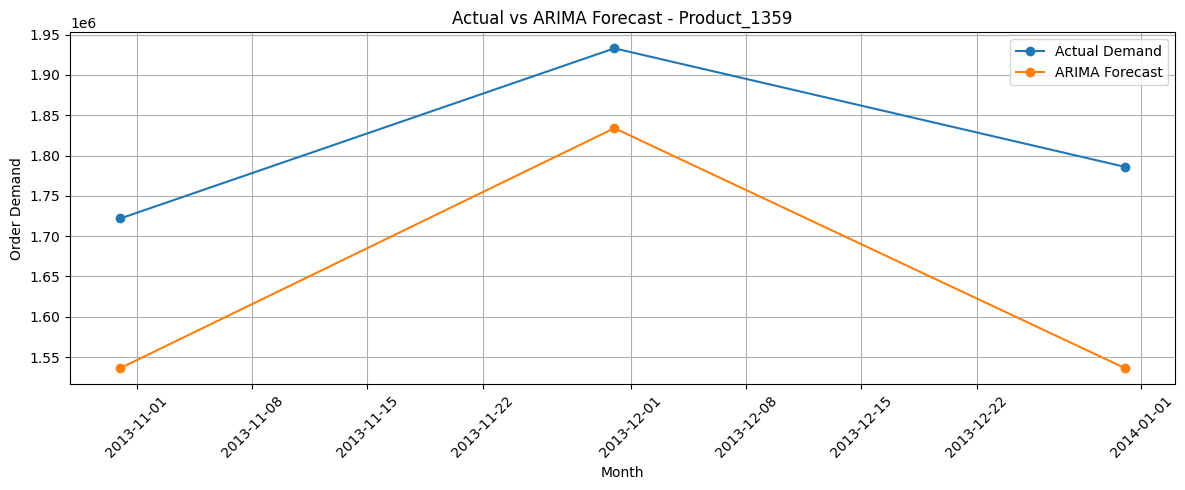

In [26]:
# Plot actual vs ARIMA forecast

plt.figure(figsize=(12, 5))

plt.plot(test.index, test.values, marker="o", label="Actual Demand")
plt.plot(test.index, arima_predictions.values, marker="o", label="ARIMA Forecast")

plt.title("Actual vs ARIMA Forecast - Product_1359")
plt.xlabel("Month")
plt.ylabel("Order Demand")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [27]:
comparison


,Model,MAE,RMSE,MAPE (%)
2,ARIMA,178068.758881,188459.617110,9.958486
0,Moving Average,261543.209877,280595.966612,14.226511
1,Exponential Smoothing,267167.930540,281392.238695,14.532176


In [28]:
# Train ARIMA on all available 2013 data

full_2013 = monthly_demand["2013"].copy()

final_model = ARIMA(full_2013, order=(1, 1, 1))
final_fitted = final_model.fit()

# Forecast the next 6 months
future_forecast = final_fitted.forecast(steps=6)

print("Next 6 Months Demand Forecast:")
print(future_forecast)


Next 6 Months Demand Forecast:
2014-01-31    2.035690e+06
2014-02-28    1.786555e+06
2014-03-31    2.035137e+06
2014-04-30    1.787107e+06
2014-05-31    2.034586e+06
2014-06-30    1.787656e+06
Freq: ME, Name: predicted_mean, dtype: float64


/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  start_params = self.start_params
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:679: EstimationWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  start_params = self.start_params


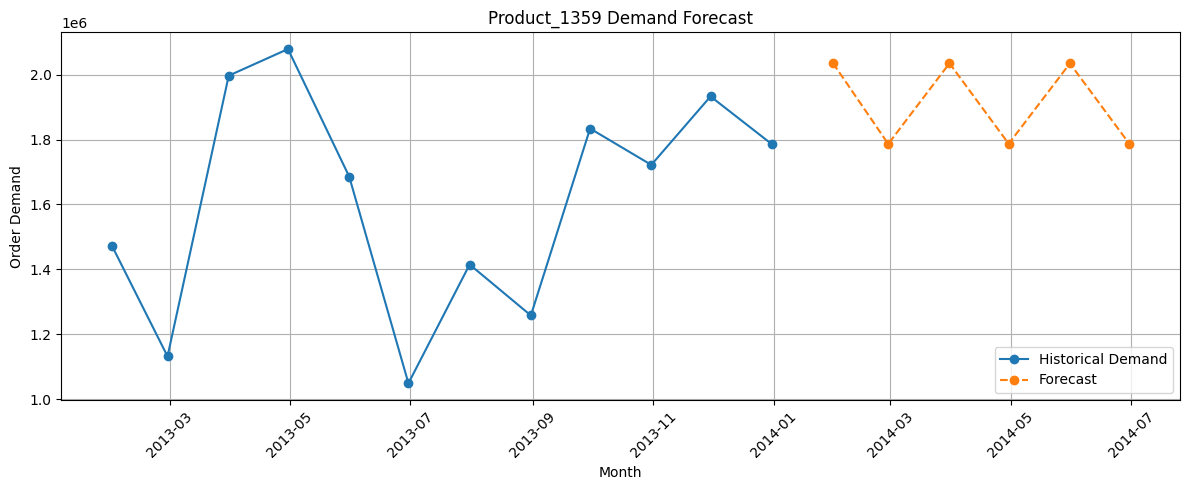

In [29]:
plt.figure(figsize=(12, 5))

plt.plot(
    full_2013.index,
    full_2013.values,
    marker="o",
    label="Historical Demand"
)

plt.plot(
    future_forecast.index,
    future_forecast.values,
    marker="o",
    linestyle="--",
    label="Forecast"
)

plt.title("Product_1359 Demand Forecast")
plt.xlabel("Month")
plt.ylabel("Order Demand")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [30]:
forecast_summary = pd.DataFrame({
    "Month": future_forecast.index,
    "Forecast_Demand": future_forecast.values
})

print(forecast_summary)

print("\nAverage monthly forecast:",
      round(future_forecast.mean()))

print("Total 6-month forecast:",
      round(future_forecast.sum()))

print("Minimum monthly forecast:",
      round(future_forecast.min()))

print("Maximum monthly forecast:",
      round(future_forecast.max()))

       Month  Forecast_Demand
0 2014-01-31     2.035690e+06
1 2014-02-28     1.786555e+06
2 2014-03-31     2.035137e+06
3 2014-04-30     1.787107e+06
4 2014-05-31     2.034586e+06
5 2014-06-30     1.787656e+06

Average monthly forecast: 1911122
Total 6-month forecast: 11466731
Minimum monthly forecast: 1786555
Maximum monthly forecast: 2035690


In [31]:
demand_std = full_2013.std()

print(f"Historical monthly demand standard deviation: {demand_std:,.2f}")

Historical monthly demand standard deviation: 343,489.98


In [32]:
avg_demand = full_2013.mean()

print(f"Average historical monthly demand: {avg_demand:,.2f}")

Average historical monthly demand: 1,613,500.00


In [33]:
# Inventory planning assumptions
lead_time_months = 1
z = 1.645  # 95% service level

safety_stock = z * demand_std * np.sqrt(lead_time_months)

reorder_point = (avg_demand * lead_time_months) + safety_stock

print(f"Safety Stock: {safety_stock:,.0f} units")
print(f"Reorder Point: {reorder_point:,.0f} units")

Safety Stock: 565,041 units
Reorder Point: 2,178,541 units


In [34]:
final_results = pd.DataFrame({
    "Metric": [
        "Best Model",
        "Test MAPE",
        "Average Monthly Forecast",
        "6-Month Forecast",
        "Safety Stock",
        "Reorder Point"
    ],
    "Value": [
        "ARIMA(1,1,1)",
        f"{mape_arima:.2f}%",
        f"{future_forecast.mean():,.0f}",
        f"{future_forecast.sum():,.0f}",
        f"{safety_stock:,.0f}",
        f"{reorder_point:,.0f}"
    ]
})

print(final_results)

                     Metric         Value
0                Best Model  ARIMA(1,1,1)
1                 Test MAPE         9.96%
2  Average Monthly Forecast     1,911,122
3          6-Month Forecast    11,466,731
4              Safety Stock       565,041
5             Reorder Point     2,178,541


## Key Results

- Best Model: ARIMA(1,1,1)
- Test MAPE: 9.96%
- Average 6-Month Forecast: 1.91 million units/month
- Total 6-Month Forecast: 11.47 million units
- Safety Stock: 565,041 units
- Reorder Point: 2,178,541 units

> Inventory figures are based on an illustrative 1-month lead-time and 95% service-level assumption.

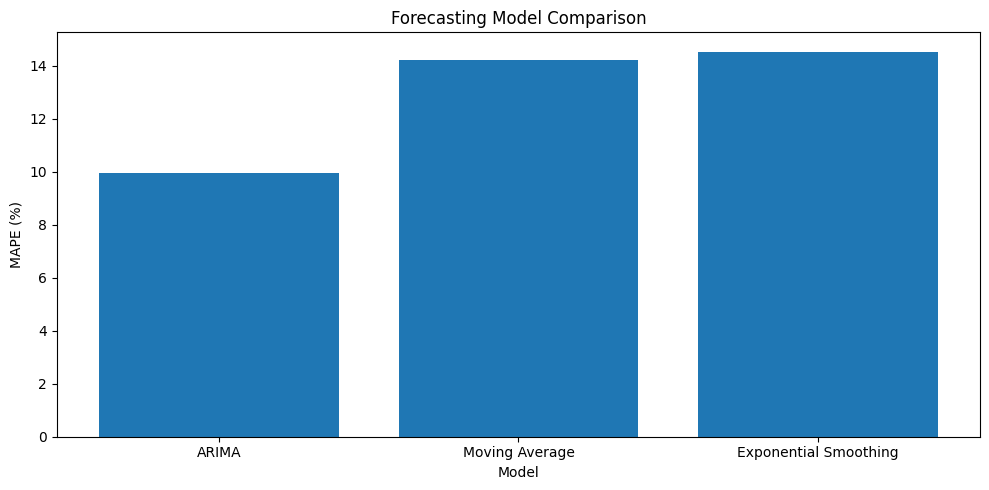

In [35]:
plt.figure(figsize=(10, 5))

plt.bar(
    comparison["Model"],
    comparison["MAPE (%)"]
)

plt.title("Forecasting Model Comparison")
plt.xlabel("Model")
plt.ylabel("MAPE (%)")

plt.tight_layout()
plt.show()